In [ ]:
import pandas as pd

# Path to your Excel file
excel_file = r"C:\Users\salop\Documents\GitHub\FAI2\2024-25c-fai2-adsai-group-group_26_y2c\datalab_tasks\task3\transcribed_data_whisper_annotation.xlsx"

# Read the Excel file
df = pd.read_excel(excel_file)

# Process only the first 150 rows.
df = df.head(150)

def calculate_wer(row):
    # Tokenize the sentence from the 'Sentence' column.
    tokens = row['Sentence'].split()
    token_count = len(tokens)
    
    # Avoid division by zero.
    if token_count == 0:
        return None
    
    # Calculate WER using the formula: (S + I + D) / N
    wer = (row['S'] + row['I'] + row['D']) / token_count
    return wer

# Apply the function to compute the WER for each row.
df['WER'] = df.apply(calculate_wer, axis=1)

# Display the first few rows with the calculated WER.
print(df[['Sentence', 'S', 'I', 'D', 'WER']].head())

# Optionally, compute the average WER over these 150 rows (ignoring rows with None as WER).
average_wer = df['WER'].dropna().mean()
print(f"\nAverage WER over the first 150 rows: {average_wer:.4f}")


                                            Sentence  S  I  D       WER
0                                  Avem triburi noi!  0  0  0  0.000000
1  Am fost bine, nu m-a plouat deloc puțin pe pic...  1  0  2  0.300000
2  Pe colegii mei din baracă am înțeles că a plou...  1  0  0  0.043478
3  Suntem aici una cu natura, adică a ieșit cumva...  0  0  0  0.000000
4  Mie îmi place foarte tare natura, îmi place fo...  0  0  0  0.000000

Average WER over the first 150 rows: 0.2909


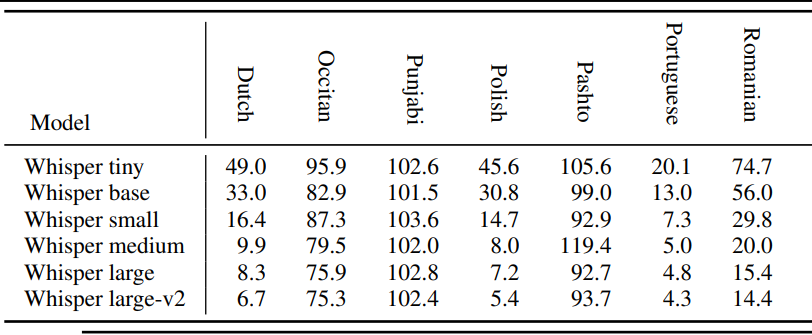 

The calculated **WER (0.29 or 29%)** is significantly **higher** than the WER reported in Radford et al. (2023) for Whisper Large **(15.4%)**, so for our particular case it worked worse than the benchmark presented in the paper.  The research paper used high-quality datasets with **clear speech and minimal background noise**. Our recordings have background noise, low-quality audio and speaker overlap. Whisper may insert or delete words based on pauses, affecting the transcript structure or if there is unclear pronunciation. We used the same formula to calculate WER as in the paper.


In [2]:
# Save the updated DataFrame to a new Excel file.
output_excel_file = r"C:\Users\salop\Documents\GitHub\FAI2\2024-25c-fai2-adsai-group-group_26_y2c\datalab_tasks\task3\transcribed_data_whisper_wer.xlsx"
df.to_excel(output_excel_file, index=False)

print(f"\nProcessed data saved to {output_excel_file}")


Processed data saved to C:\Users\salop\Documents\GitHub\FAI2\2024-25c-fai2-adsai-group-group_26_y2c\datalab_tasks\task3\transcribed_data_whisper_wer.xlsx
